# Маскирование действий в среде такси

ссылка на описание игры

https://gymnasium.farama.org/environments/toy_text/taxi/

Эта среда является частью серии «Игрушечные тексты», которая содержит общую информацию об окружающей обстановке.

Число действий: Discrete(6)

Число состояний: Discrete(500)

Загрузка: gymnasium.make("Taxi-v3")

Задача "Такси" заключается в том, чтобы найти пассажиров в мире, расположенном по сетке, забрать их и высадить в одном из четырех мест.

В мире, представляющем собой сетку 5x5, есть четыре обозначенных места посадки и высадки (красное, зеленое, желтое и синее). Такси начинает движение со случайной клетки, а пассажир — с одной из обозначенных точек.

Цель игры — переместить такси к месту нахождения пассажира, забрать пассажира, доставить его в желаемое место назначения и высадить. После высадки пассажира игра заканчивается.

Игрок получает положительное вознаграждение за успешную высадку пассажира в нужном месте. Отрицательное вознаграждение начисляется за неправильные попытки посадки/высадки пассажира, а также за каждый шаг, на котором не получено другое вознаграждение.

Карта:

    +---------+
    |R: | : :G|
    | : | : : |
    | : : : : |
    | | : | : |
    |Y| : |B: |
    +---------+

Из книги Тома Дитериха «Иерархическое обучение с подкреплением с разложением функции ценности MAXQ»

ссылка на книгу

[1] T. G. Dietterich, “Hierarchical Reinforcement Learning with the MAXQ Value Function Decomposition,” Journal of Artificial Intelligence Research, vol. 13, pp. 227–303, Nov. 2000, doi: 10.1613/jair.639.

## Понимание среды такси

Пространство действий

Форма действия (1,) находится в диапазоне {0, 5} и указывает направление движения такси или место посадки/высадки пассажиров.

В среде такси возможны 6 действий:

- 0: Move south (вниз)
- 1: Move north (вверх)
- 2: Move east (вправо)
- 3: Move west (влево)
- 4: Pickup passenger (Забрать пассажира)
- 5: Drop off passenger (Высадка пассажира)

Пространство наблюдений

Существует 500 дискретных состояний, поскольку есть 25 позиций такси, 5 возможных местоположений пассажира (включая случай, когда пассажир находится в такси) и 4 пункта назначения.

Пункты назначения на карте обозначаются первой буквой цвета.

Местоположения пассажиров:

0: Красный

1: Зеленый

2: Желтый

3: Синий

4: В такси

Пункты назначения:

0: Красный

1: Зеленый

2: Желтый

3: Синий

Наблюдение возвращается в виде целого числа (int()), кодирующего соответствующее состояние, вычисленное по формуле ((taxi_row * 5 + taxi_col) * 5 + passenger_location) * 4 + destination

Обратите внимание, что в течение эпизода может быть достигнуто 400 состояний. Отсутствующие состояния соответствуют ситуациям, когда пассажир находится в том же месте, что и пункт назначения, поскольку это обычно сигнализирует об окончании эпизода. После успешного завершения операции, когда и пассажир, и такси находятся в пункте назначения, можно наблюдать еще четыре состояния. Таким образом, общее количество достижимых дискретных состояний составляет 404.

Начальное состояние

Начальное состояние выбирается равномерно из возможных состояний, в которых пассажир не находится ни в пункте назначения, ни внутри такси. Существует 300 возможных начальных состояний: 25 положений такси, 4 местоположения пассажира (исключая местоположение внутри такси) и 3 пункта назначения (исключая текущее местоположение пассажира).

Награды

-1 за каждый шаг, если не активирована другая награда.

+20 за доставку пассажира.

-10 за незаконное выполнение действий «забор» и «высадка».

Действие, приводящее к пустому действию, например, столкновение со стеной, повлечет за собой штраф за шаг времени. Путевых действий можно избежать, используя выборку action_mask, возвращаемого в info.

Конец эпизода

Эпизод заканчивается, если происходит следующее:

Завершение: 1. Такси высаживает пассажира.

Усечение (при использовании обертки time_limit): 1. Длительность эпизода составляет 200.

Информация

Функции step() и reset() возвращают словарь со следующими ключами:

p - вероятность перехода в состояние.

action_mask - если действия приведут к переходу в новое состояние.

В некоторых случаях выполнение действия не повлияет на состояние эпизода. В версии 0.25.0 info["action_mask"] содержит np.ndarray для каждого из действий, указывающий, изменит ли действие состояние.

Для выборки изменяющего действия используйте action = env.action_space.sample(info["action_mask"]) Или с алгоритмом на основе Q-значения action = np.argmax(q_values[obs, np.where(info["action_mask"] == 1)[0]]).

Аргументы

import gymnasium as gym
gym.make('Taxi-v3')
is_raining=False: Если True, такси будет двигаться в заданном направлении с вероятностью 80%, в противном случае будет двигаться влево или вправо от целевого направления с равной вероятностью 10% в обоих направлениях.

fickle_passenger=False: Если True, у пассажира есть 30% шанс сменить пункт назначения, когда такси переместилось на одну клетку от исходного местоположения пассажира. Непостоянство пассажира проявляется только при первой посадке и успешном перемещении. Если пассажир высажен в исходном местоположении и снова посажен, это не срабатывает.

Среда такси — это классическая задача в мире сетки, где такси должно забрать пассажира и доставить его в пункт назначения. В этой среде не все действия допустимы в каждом состоянии — например, нельзя проезжать сквозь стены или забирать пассажира, когда вы не находитесь в его местоположении.

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
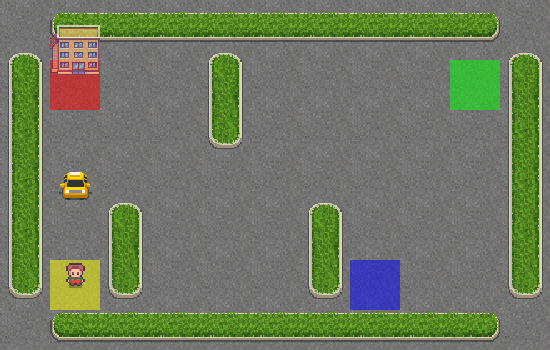

In [ ]:
# зададим игру Taxi-v3
env = gym.make("Taxi-v3", render_mode='rgb_array')

# переведем игру в начальное состояние
env.reset()
# визуализируем среду
env.render()

In [ ]:
env.action_space    # количество действий

Discrete(6)

In [ ]:
env.action_space.sample() # случайное действие

np.int64(5)

In [ ]:
env.observation_space # пространство состояний

Discrete(500)

В этом руководстве показано, как использовать маскирование действий в среде такси для повышения эффективности обучения с подкреплением путем предотвращения недопустимых действий.

Маскирование действий — это метод, который помогает агентам обучения с подкреплением избегать выбора недопустимых действий, предоставляя бинарную маску, указывающую, какие действия допустимы в текущем состоянии. Это может значительно повысить эффективность и производительность обучения.

Среда предоставляет ``action_mask`` в словаре информации, возвращаемом функциями ``reset()`` и ``step()``.
Эта маска представляет собой бинарный массив, где 1 указывает на допустимое действие, а 0 — на недопустимое.

next_state= 268
info= {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)}
info["prob"]= 1.0
info["action_mask"]= [1 1 1 1 0 0]


array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
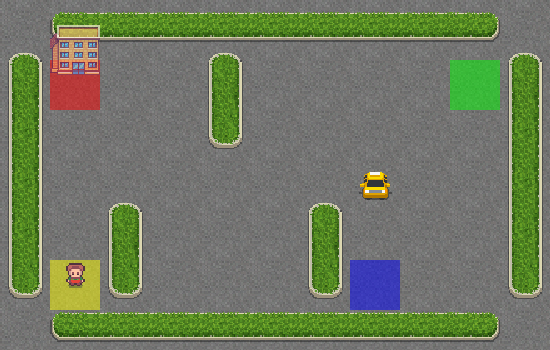

In [ ]:
next_state,  info = env.reset()                    # переведем игру в начальное состояние
print('next_state=', next_state)                   # номер состояния
print('info=', info)                               # информация о состоянии
print('info["prob"]=',info["prob"])
print('info["action_mask"]=',info["action_mask"])
env.render()                                       # выводим картинку на экран

next_state= 368
reward= -1
done= False
truncated= False
info= {'prob': 1.0, 'action_mask': array([1, 1, 1, 0, 0, 0], dtype=int8)}
info["prob"]= 1.0
info["action_mask"]= [1 1 1 0 0 0]


array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
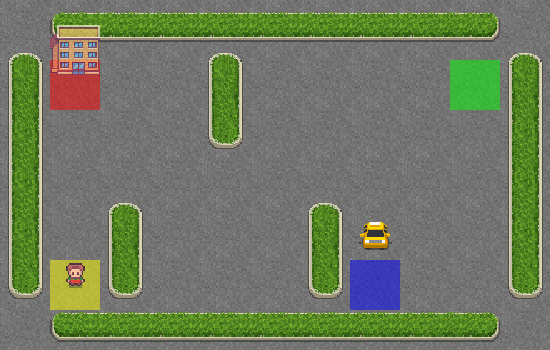

In [ ]:
action=0
next_state, reward, done, truncated, info = env.step(action)
print('next_state=', next_state)
print('reward=', reward)
print('done=', done)
print('truncated=', truncated)
print('info=',info)
print('info["prob"]=',info["prob"])
print('info["action_mask"]=',info["action_mask"])
env.render()

## Как работает маскирование действий

Маскирование действий работает за счет ограничения выбора действий агентом только допустимыми действиями:

1. Во время исследования: При выборе случайных действий мы выбираем только из набора допустимых действий.
2. Во время эксплуатации: При выборе наилучшего действия на основе Q-значений мы учитываем только Q-значения для допустимых действий.
3. Во время обновлений Q-обучения: Мы вычисляем максимальное будущее Q-значение только для допустимых действий в следующем состоянии.

Давайте реализуем это шаг за шагом:


In [ ]:
import random
from pathlib import Path

# Начальное значение генератора случайных чисел для обеспечения воспроизводимости результатов.
BASE_RANDOM_SEED = 58922320


def train_q_learning(
    env,
    use_action_mask: bool = True,
    episodes: int = 5000,
    seed: int = BASE_RANDOM_SEED,
    learning_rate: float = 0.1,
    discount_factor: float = 0.95,
    epsilon: float = 0.1,
) -> dict:
    """Обучите агента Q-обучения с маскированием действий или без него"""
    # Установите случайные начальные значения для обеспечения воспроизводимости результатов.
    np.random.seed(seed)
    random.seed(seed)

    # Инициализация таблицы Q
    n_states = env.observation_space.n
    n_actions = env.action_space.n
    q_table = np.zeros((n_states, n_actions))

    # Отслеживайте награды за эпизоды для анализа
    episode_rewards = []

    for episode in range(episodes):
        # Сброс среды
        state, info = env.reset(seed=seed + episode)
        total_reward = 0
        done = False
        truncated = False

        while not (done or truncated):
            # Получить маску действий, если используется
            action_mask = info["action_mask"] if use_action_mask else None

            # Выбор действий с помощью алгоритма Epsilon-жадности и маскирования
            if np.random.random() < epsilon:
                # Случайный выбор действия
                if use_action_mask:
                    # Выбирайте только из допустимых действий
                    valid_actions = np.nonzero(action_mask == 1)[0]
                    action = np.random.choice(valid_actions)
                else:
                    # Выберите из всех действий
                    action = np.random.randint(0, n_actions)
            else:
                # Жадный выбор действий
                if use_action_mask:
                    # Рассматривайте только допустимые действия для эксплуатации
                    valid_actions = np.nonzero(action_mask == 1)[0]
                    if len(valid_actions) > 0:
                        action = valid_actions[np.argmax(q_table[state, valid_actions])]
                    else:
                        action = np.random.randint(0, n_actions)
                else:
                    # Рассмотрите все действия
                    action = np.argmax(q_table[state])

            # Примите меры и понаблюдайте за результатом
            next_state, reward, done, truncated, info = env.step(action)
            total_reward += reward

            # Обновление Q-обучения
            if not (done or truncated):
                if use_action_mask:
                    # При создании собственной платформы следует рассматривать только допустимые дальнейшие действия
                    next_mask = info["action_mask"]
                    valid_next_actions = np.nonzero(next_mask == 1)[0]
                    if len(valid_next_actions) > 0:
                        next_max = np.max(q_table[next_state, valid_next_actions])
                    else:
                        next_max = 0
                else:
                    # Рассмотрите все дальнейшие действия
                    next_max = np.max(q_table[next_state])

                # Обновить значение Q
                q_table[state, action] = q_table[state, action] + learning_rate * (
                    reward + discount_factor * next_max - q_table[state, action]
                )

            state = next_state

        episode_rewards.append(total_reward)

    return {
        "episode_rewards": episode_rewards,
        "mean_reward": np.mean(episode_rewards),
        "std_reward": np.std(episode_rewards),
    }

# Проведение эксперимента

Теперь мы проведем эксперименты для сравнения производительности агентов Q-обучения с маскированием действий и без него.
Для обеспечения надежного статистического сравнения мы будем использовать несколько случайных начальных значений.

Настройка эксперимента:
- 12 независимых запусков с разными случайными начальными значениями
- 5000 эпизодов на запуск
- Стандартные гиперпараметры Q-обучения ``(α=0.1, γ=0.95, ε=0.1)``




In [ ]:
# Параметры эксперимента
n_runs = 12
episodes = 5000
learning_rate = 0.1
discount_factor = 0.95
epsilon = 0.1

# Для каждого запуска генерируйте разные начальные значения
seeds = [BASE_RANDOM_SEED + i for i in range(n_runs)]

# Сохраните результаты для сравнения
masked_results_list = []
unmasked_results_list = []

# Проведите эксперименты с разными seeds
for i, seed in enumerate(seeds):
    print(f"Run {i + 1}/{n_runs} with seed {seed}")

    # Тренировочный агент с маскировкой действий
    env_masked = gym.make("Taxi-v3")
    masked_results = train_q_learning(
        env_masked,
        use_action_mask=True,
        seed=seed,
        learning_rate=learning_rate,
        discount_factor=discount_factor,
        epsilon=epsilon,
        episodes=episodes,
    )
    env_masked.close()
    masked_results_list.append(masked_results)

    # Помощник тренера БЕЗ маскировки действий
    env_unmasked = gym.make("Taxi-v3")
    unmasked_results = train_q_learning(
        env_unmasked,
        use_action_mask=False,
        seed=seed,
        learning_rate=learning_rate,
        discount_factor=discount_factor,
        epsilon=epsilon,
        episodes=episodes,
    )
    env_unmasked.close()
    unmasked_results_list.append(unmasked_results)

Run 1/12 with seed 58922320
Run 2/12 with seed 58922321
Run 3/12 with seed 58922322
Run 4/12 with seed 58922323
Run 5/12 with seed 58922324
Run 6/12 with seed 58922325
Run 7/12 with seed 58922326
Run 8/12 with seed 58922327
Run 9/12 with seed 58922328
Run 10/12 with seed 58922329
Run 11/12 with seed 58922330
Run 12/12 with seed 58922331


# Визуализация результатов

После проведения всех экспериментов мы рассчитываем статистические данные и создаем визуализации для сравнения эффективности обоих подходов.




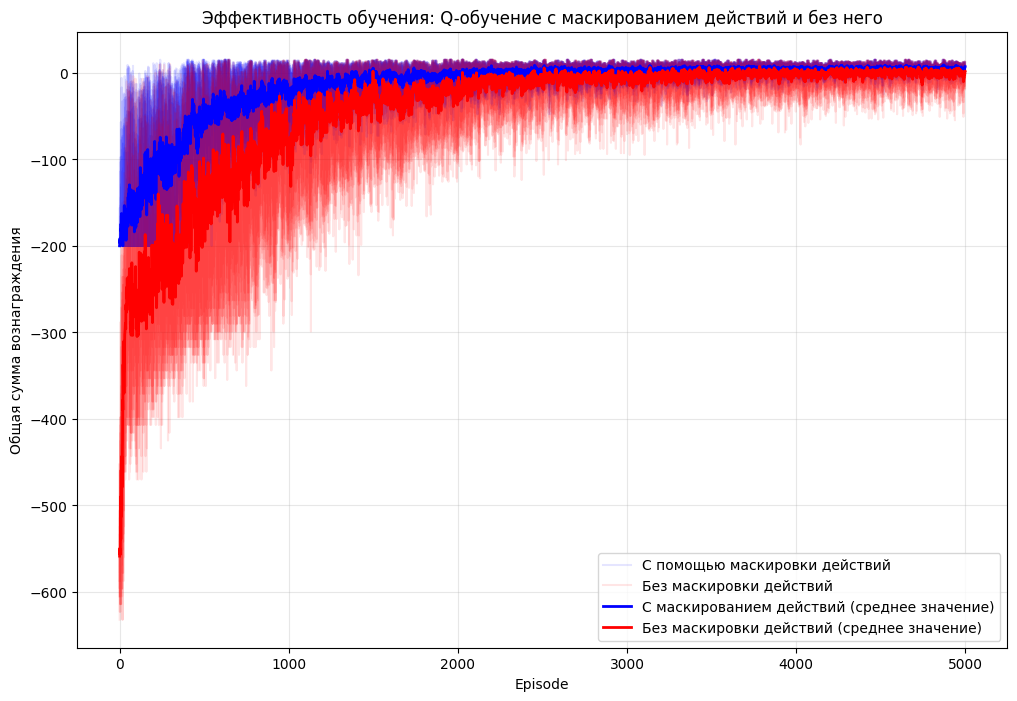

In [ ]:
# Рассчитайте статистические данные по всем запускам
masked_mean_rewards = [r["mean_reward"] for r in masked_results_list]
unmasked_mean_rewards = [r["mean_reward"] for r in unmasked_results_list]

masked_overall_mean = np.mean(masked_mean_rewards)
masked_overall_std = np.std(masked_mean_rewards)
unmasked_overall_mean = np.mean(unmasked_mean_rewards)
unmasked_overall_std = np.std(unmasked_mean_rewards)

# Создать визуализацию
plt.figure(figsize=(12, 8), dpi=100)

# Постройте графики отдельных запусков с низким уровнем значимости альфа
for i, (masked_results, unmasked_results) in enumerate(
    zip(masked_results_list, unmasked_results_list)
):
    plt.plot(
        masked_results["episode_rewards"],
        label="С помощью маскировки действий" if i == 0 else None,
        color="blue",
        alpha=0.1,
    )
    plt.plot(
        unmasked_results["episode_rewards"],
        label="Без маскировки действий" if i == 0 else None,
        color="red",
        alpha=0.1,
    )

# Рассчитать и построить средние кривые по всем запускам
masked_mean_curve = np.mean([r["episode_rewards"] for r in masked_results_list], axis=0)
unmasked_mean_curve = np.mean(
    [r["episode_rewards"] for r in unmasked_results_list], axis=0
)

plt.plot(
    masked_mean_curve, label="С маскированием действий (среднее значение)", color="blue", linewidth=2
)
plt.plot(
    unmasked_mean_curve,
    label="Без маскировки действий (среднее значение)",
    color="red",
    linewidth=2,
)

plt.xlabel("Episode")
plt.ylabel("Общая сумма вознаграждения")
plt.title("Эффективность обучения: Q-обучение с маскированием действий и без него")
plt.legend()
plt.grid(True, alpha=0.3)

# Сохраните рисунок
savefig_folder = Path("_static/img/tutorials/")
savefig_folder.mkdir(parents=True, exist_ok=True)
plt.savefig(
    savefig_folder / "taxi_v3_action_masking_comparison.png",
    bbox_inches="tight",
    dpi=150,
)
plt.show()

<img src="file://_static/img/tutorials/taxi_v3_action_masking_comparison.png">

# Анализ результатов

Сравнение демонстрирует несколько важных преимуществ использования маскировки действий:

Основные преимущества маскировки действий:

1. Более быстрая сходимость: Агенты с маскировкой действий, как правило, обучаются быстрее, поскольку не тратят время на изучение
недопустимых действий.

2. Лучшая производительность: Сосредоточившись только на допустимых действиях, агент может более стабильно получать более высокие вознаграждения.

3. Более стабильное обучение: Маскировка действий уменьшает дисперсию в обучении, устраняя случайность, связанную с выбором недопустимых действий.

4. Практическая применимость: В реальных сценариях маскировка действий предотвращает совершение агентами действий, которые могут быть опасными или невозможными.

Напоминание о ключевых деталях реализации

- Выбор действий: Мы фильтруем доступные действия с помощью ``np.nonzero(action_mask == 1)[0]``, чтобы получить только допустимые действия.
- Обновление Q-значения: При вычислении максимального будущего Q-значения мы учитываем только допустимые действия в следующем состоянии.
- Исследование: Случайный выбор действий ограничен набором допустимых действий.

Этот подход гарантирует, что агент никогда не выберет недопустимые действия, сохраняя при этом баланс между исследованием и использованием, необходимый для эффективного обучения.



# Задание для самостоятельного выполнения

Реализуйте алгоритмы c маскированием действий

1.$Q(s_t, a_t)=(1-\alpha)Q(s_t, a_t)+\alpha(R_{t+1}+max_a Q(s_{t+1},a))$

$\alpha = 0.1$


2.$Q(s_t, a_t)=Q(s_t, a_t)+\alpha(R_{t+1}+\gamma max_a Q(s_{t+1},a)-Q(s_t, a_t))$

$\alpha = 0.1$, $\gamma = 0.9$

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
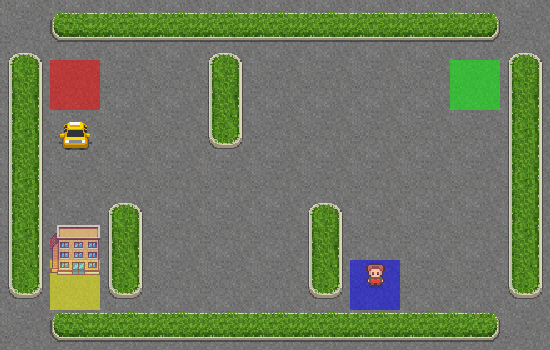

In [ ]:
# зададим игру Taxi-v3
env = gym.make("Taxi-v3", render_mode='rgb_array')

# переведем игру в начальное состояние
env.reset()
# визуализируем среду
env.render()

1. Q(st,at)=(1−α)Q(st,at)+α(Rt+1+maxaQ(st+1,a))

α=0.1

In [ ]:
def train_q_learning_variant1(
    env,
    seed=42,
    learning_rate=0.1,
    discount_factor=1.0,
    episodes=10000,
    epsilon=0.1,
    epsilon_decay=None,
    min_epsilon=0.01,
):
    np.random.seed(seed)
    env.reset(seed=seed)

    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))
    episode_rewards = []

    for episode in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            # Маска допустимых действий
            action_mask = env.unwrapped.action_mask(state)
            valid_actions = np.nonzero(action_mask)[0]

            # ε-жадная стратегия
            if np.random.rand() < epsilon:
                action = np.random.choice(valid_actions)
            else:
                action = valid_actions[np.argmax(Q[state, valid_actions])]

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            # Маска следующего состояния
            next_mask = env.unwrapped.action_mask(next_state)
            next_valid_actions = np.nonzero(next_mask)[0]
            max_next_q = np.max(Q[next_state, next_valid_actions])

            # Классическое обновление Q
            Q[state, action] += learning_rate * (reward + discount_factor * max_next_q - Q[state, action])

            state = next_state

        episode_rewards.append(total_reward)

        # Применяем ε-decay
        if epsilon_decay is not None:
            epsilon = max(min_epsilon, epsilon * epsilon_decay)

    return {
        "Q": Q,
        "episode_rewards": episode_rewards,
        "mean_reward": np.mean(episode_rewards),
        "std_reward": np.std(episode_rewards),
    }

In [ ]:
result_v1 = train_q_learning_variant1(env)


print("Variant 1")
print("Mean reward:", result_v1["mean_reward"])
print("Std reward:", result_v1["std_reward"])


Variant 1
Mean reward: 1.459
Std reward: 24.399608992768716


2. Q(st,at)=Q(st,at)+α(Rt+1+γmaxaQ(st+1,a)−Q(st,at))

α=0.1 ,  γ=0.9

In [ ]:
def train_q_learning_variant2(
    env,
    seed=42,
    learning_rate=0.1,
    discount_factor=0.9,
    episodes=10000,
    epsilon=0.1,
    epsilon_decay=None,
    min_epsilon=0.01,
):
    """
    Q-learning с маской допустимых действий (Variant 2) и поддержкой ε-decay
    """
    np.random.seed(seed)
    env.reset(seed=seed)

    n_states = env.observation_space.n
    n_actions = env.action_space.n

    Q = np.zeros((n_states, n_actions))
    episode_rewards = []

    for episode in range(episodes):
        state, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            # ✅ Маска допустимых действий
            action_mask = env.unwrapped.action_mask(state)
            valid_actions = np.nonzero(action_mask)[0]

            # ε-жадная стратегия
            if np.random.rand() < epsilon:
                action = np.random.choice(valid_actions)
            else:
                action = valid_actions[np.argmax(Q[state, valid_actions])]

            # Шаг в среде
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total_reward += reward

            # ✅ Маска следующего состояния
            next_mask = env.unwrapped.action_mask(next_state)
            next_valid_actions = np.nonzero(next_mask)[0]
            max_next_q = np.max(Q[next_state, next_valid_actions])

            # ✅ Классическое обновление Q
            Q[state, action] += learning_rate * (
                reward + discount_factor * max_next_q - Q[state, action]
            )

            state = next_state

        episode_rewards.append(total_reward)

        # Применяем ε-decay
        if epsilon_decay is not None:
            epsilon = max(min_epsilon, epsilon * epsilon_decay)

    return {
        "Q": Q,
        "episode_rewards": episode_rewards,
        "mean_reward": np.mean(episode_rewards),
        "std_reward": np.std(episode_rewards),
    }

In [ ]:
result_v2 = train_q_learning_variant2(env)

print("Variant 2")
print("Mean reward:", result_v2["mean_reward"])
print("Std reward:", result_v2["std_reward"])

Variant 2
Mean reward: 1.0905
Std reward: 25.01356251616311
